lab4
\
jaber alsaikhan
\
2240006539

# ARTI 404 - Image Processing
## Lab 4: Intensity Transformations and Filtering - Spatial Domain

Outcome#2: Write a program that implements fundamental image processing
algorithms.

The manual's thresholding step reads `../images/Parrot.png`. That file is not
part of this repository, so Step 0 checks for it and, if it is missing,
writes a stand-in from skimage's built-in sample data (`coffee.png`). Drop the
course's `Parrot.png` into `labs/images/` and the notebook uses it instead.
The histogram tasks use `data.moon()`, `data.rocket()` and `data.chelsea()`
directly, exactly as the manual asks, and Step 0 also saves copies of them so
the Lab 4 folder contains the images used.

Display is done with matplotlib rather than `cv2.imshow`/`cv2.waitKey`, so the
notebook runs top to bottom without opening OS windows.

In [1]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, exposure, io

## Step 0: Prepare the working images on disk

In [2]:
# __file__ is undefined inside a notebook kernel, which starts in the notebook's
# own directory, so fall back to the working directory there.
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()

IMAGES_DIR = os.path.join(HERE, "..", "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

PARROT_PATH = os.path.join(IMAGES_DIR, "Parrot.png")
if os.path.exists(PARROT_PATH):
    THRESH_PATH = PARROT_PATH
else:
    THRESH_PATH = os.path.join(IMAGES_DIR, "coffee.png")  # stands in for Parrot.png
    io.imsave(THRESH_PATH, data.coffee(), check_contrast=False)

# Save the skimage sample images used by Task 2 and the assessment.
for name in ("moon", "rocket", "chelsea"):
    io.imsave(os.path.join(IMAGES_DIR, f"{name}.png"), getattr(data, name)(), check_contrast=False)

print("Thresholding image:", os.path.basename(THRESH_PATH))
print("Images dir:", os.path.normpath(IMAGES_DIR))

Thresholding image: coffee.png
Images dir: c:\Users\jaber\OneDrive\Desktop\Image Processing\labs\images


## Task#1: Thresholding

### Step#1: Apply thresholding with a fixed threshold on an image

Thresholding converts a grayscale image into a binary one: every pixel above
the threshold becomes white (foreground, 255) and every pixel at or below it
becomes black (background, 0). `cv2.threshold` with `cv2.THRESH_BINARY`
returns the threshold it used and the binary image. Sweeping the threshold
shows how the choice of value decides what counts as foreground: at 0 almost
everything is foreground, at 200 only the brightest regions survive.

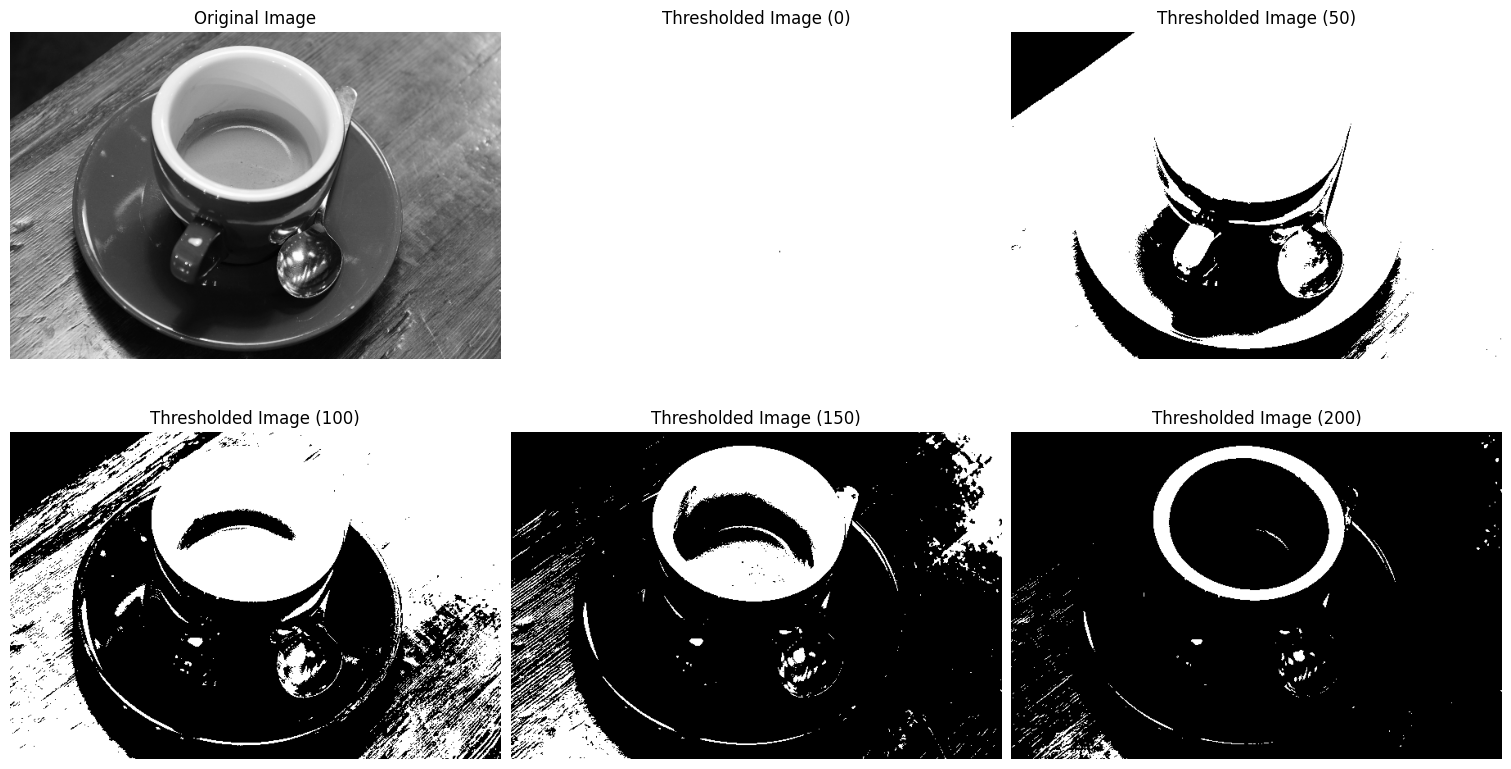

In [3]:
# Load the image in grayscale
img = cv2.imread(THRESH_PATH, cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

fig, axs = plt.subplots(2, 3, figsize=(15, 8), layout="constrained")
axs = axs.ravel()

# Display the original image
axs[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axs[0].set_title("Original Image")

# Apply thresholding with different threshold values
for ax, threshold_value in zip(axs[1:], threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    ax.imshow(thresh, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Thresholded Image ({threshold_value})")

for ax in axs:
    ax.axis("off")
plt.show()

## Task#2: Histogram Processing

### Step#1: Load necessary libraries

Already imported at the top of the notebook (`matplotlib.pyplot`, `numpy`,
`skimage.data`, `skimage.exposure`).

### Step#2: Load moon image

In [4]:
img = data.moon()
print("dtype:", img.dtype, "shape:", img.shape, "range:", img.min(), "-", img.max())

dtype: uint8 shape: (512, 512) range: 0 - 255


### Step#3: Contrast stretching (2nd-98th percentile)

`np.percentile` finds the gray levels below which 2% and 98% of the pixels
fall. `exposure.rescale_intensity` then maps that range linearly onto the full
0-255 range, clipping the few pixels outside it. This ignores outliers, so a
handful of very dark or very bright pixels don't prevent the stretch.

In [5]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
print(f"2nd percentile = {p2}, 98th percentile = {p98}")

2nd percentile = 78.0, 98th percentile = 129.0


### Step#4: Display the image with its histogram for Step#2 and Step#3

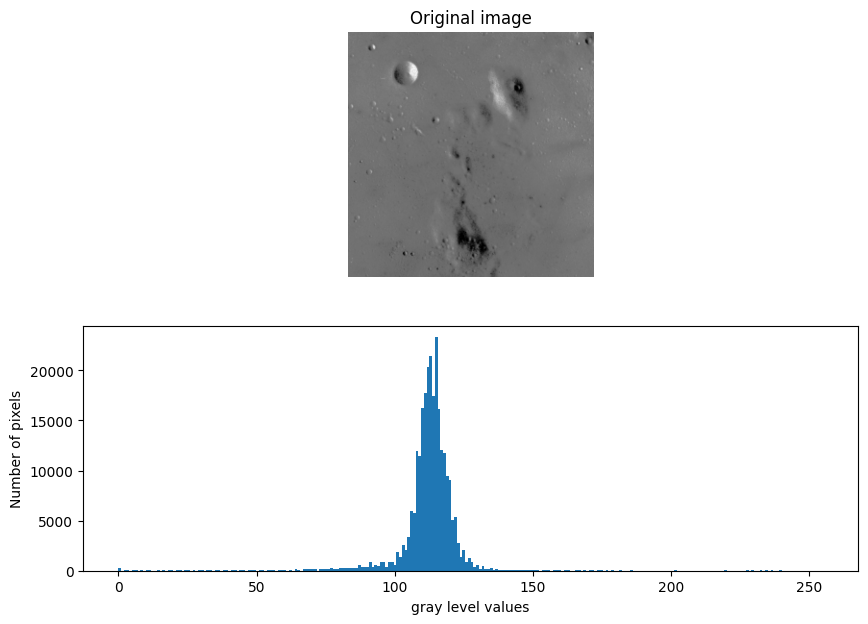

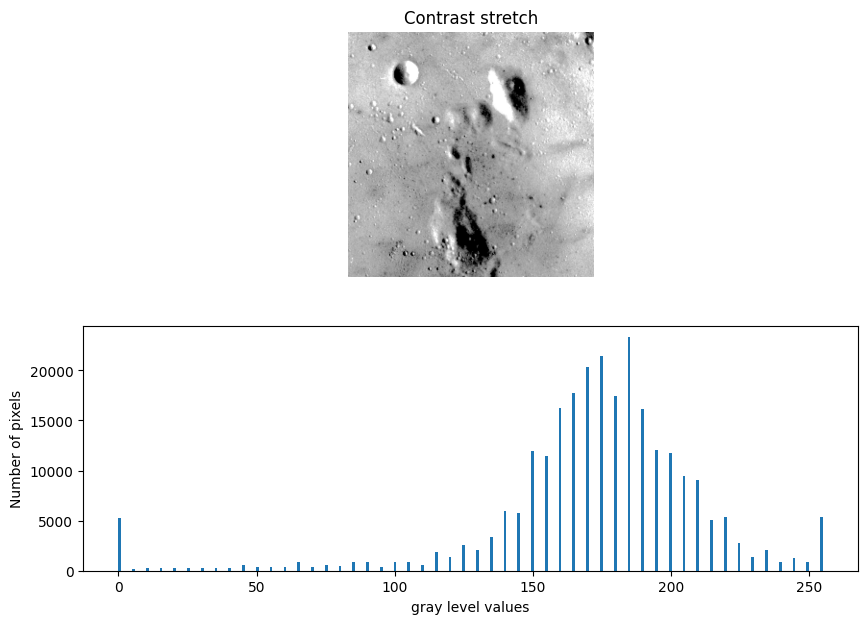

In [6]:
def show_with_hist(image, title):
    """Image on top, its 256-bin gray-level histogram underneath."""
    fig = plt.figure(figsize=(10, 7))
    fig.add_subplot(2, 1, 1)
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.axis("off")
    plt.title(title)
    fig.add_subplot(2, 1, 2)
    plt.hist(image.flat, bins=256, range=(0, 255))
    plt.xlabel("gray level values")
    plt.ylabel("Number of pixels")
    plt.show()


show_with_hist(img, "Original image")
show_with_hist(img_rescale, "Contrast stretch")

The original moon histogram is packed into a narrow band of gray levels, which
is why the image looks flat. After stretching, the same histogram shape is
spread across the full 0-255 range, so the craters stand out.

## Assessment

### Task#1: Contrast stretching between the 3rd and 80th percentiles

Same method as Step#3, with a different input range. Because the upper limit
is now the 80th percentile, the brightest 20% of pixels are all clipped to
255, so bright areas saturate and lose detail while the darker majority gets
a stronger stretch.

3rd percentile = 87.0, 80th percentile = 118.0
Pixels clipped to 255: 21.0%


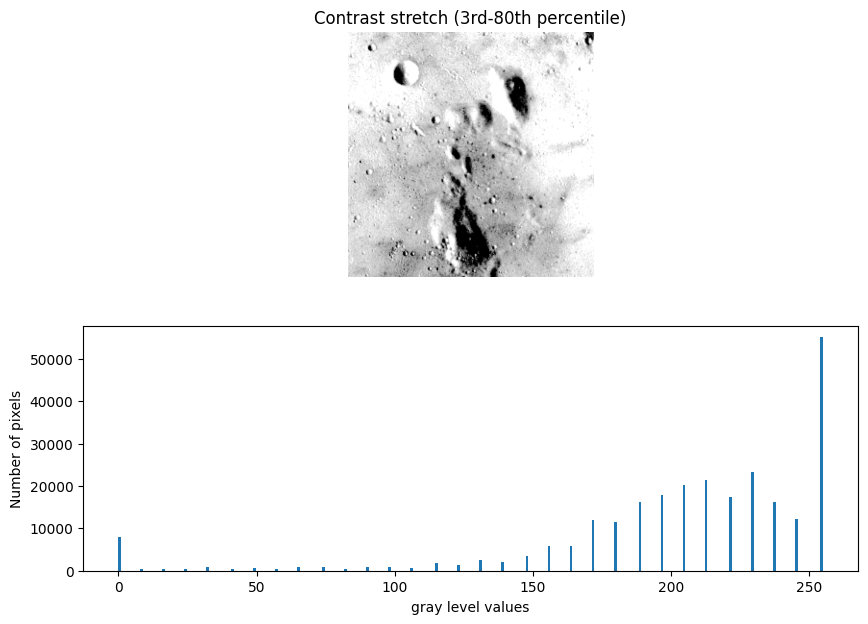

In [7]:
img = data.moon()

p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))
print(f"3rd percentile = {p3}, 80th percentile = {p80}")
print(f"Pixels clipped to 255: {np.mean(img_rescale_3_80 == 255):.1%}")

show_with_hist(img_rescale_3_80, "Contrast stretch (3rd-80th percentile)")

### Task#2: Histogram equalization

`exposure.equalize_hist` maps each gray level through the image's cumulative
distribution function (CDF), so the output histogram is as close to flat as
the discrete levels allow. It returns floats in [0, 1], so the result is
scaled back to 0-255 for display and for the 0-255 histogram.

The cumulative histogram (red) makes the effect easy to see: for the original
it rises steeply over a narrow range; after equalization it is close to a
straight line.

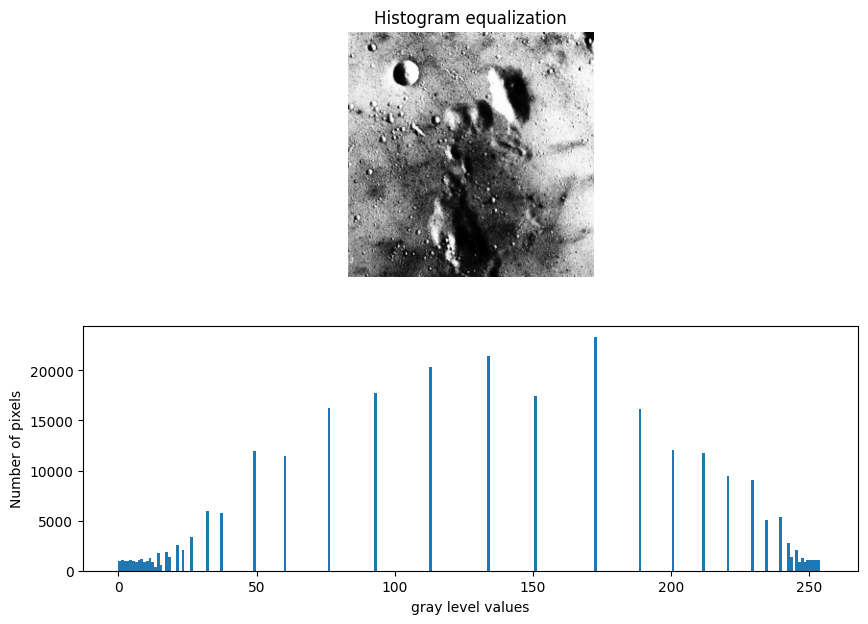

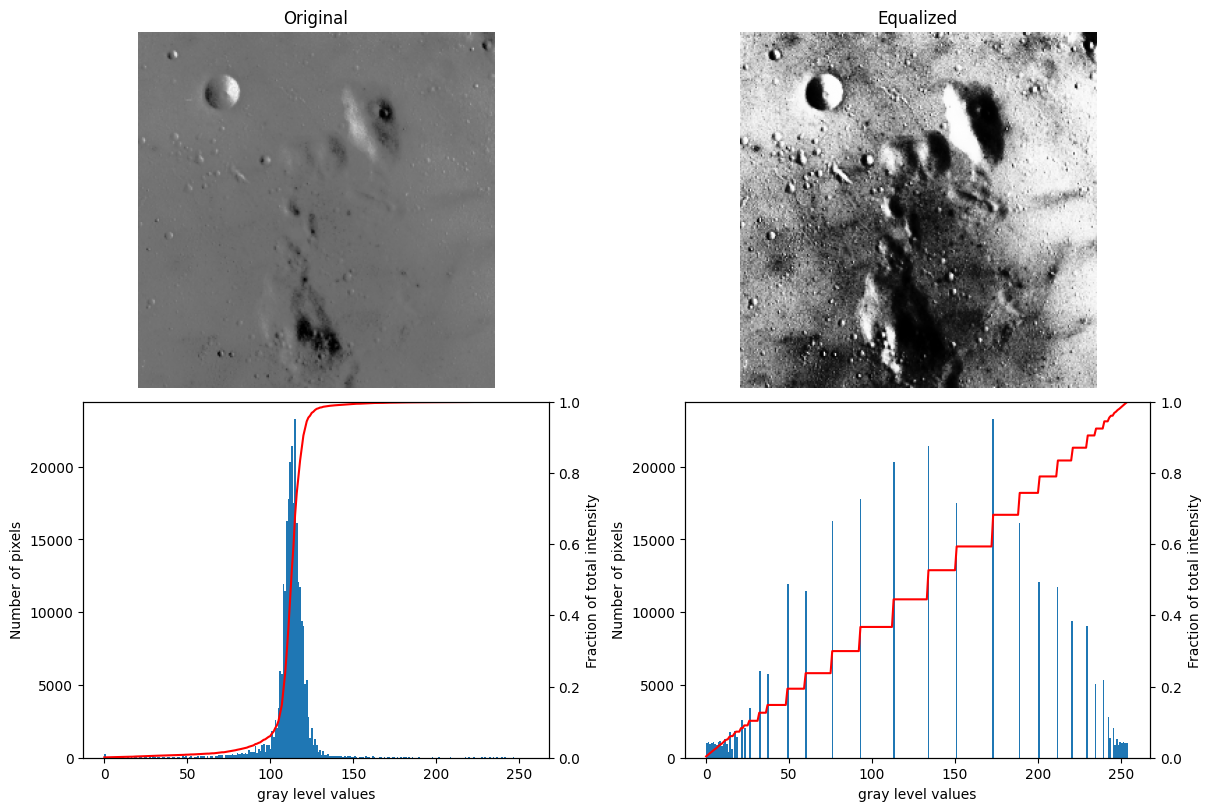

In [8]:
img = data.moon()
img_eq = (exposure.equalize_hist(img) * 255).astype(np.uint8)

show_with_hist(img_eq, "Histogram equalization")

# Original vs. equalized, with cumulative distribution overlaid.
fig, axs = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
for col, (im, title) in enumerate([(img, "Original"), (img_eq, "Equalized")]):
    axs[0, col].imshow(im, cmap="gray", vmin=0, vmax=255)
    axs[0, col].set_title(title)
    axs[0, col].axis("off")

    ax = axs[1, col]
    ax.hist(im.ravel(), bins=256, range=(0, 255))
    ax.set_xlabel("gray level values")
    ax.set_ylabel("Number of pixels")
    cdf, bins = exposure.cumulative_distribution(im, 256)
    ax_cdf = ax.twinx()
    ax_cdf.plot(bins, cdf, "r")
    ax_cdf.set_ylim(0, 1)
    ax_cdf.set_ylabel("Fraction of total intensity")
plt.show()

### Task#3: Histogram matching

Histogram matching (specification) transforms the source image so its
histogram matches a reference image's. `exposure.match_histograms` does this
per color channel when `channel_axis=-1`. Here the source is `chelsea` (the
cat) and the reference is `rocket`; the cat picks up the rocket photo's
colors and tonal distribution. Rocket is 427x640 and Chelsea is 300x451; the
images don't need the same size, since only their histograms are compared.

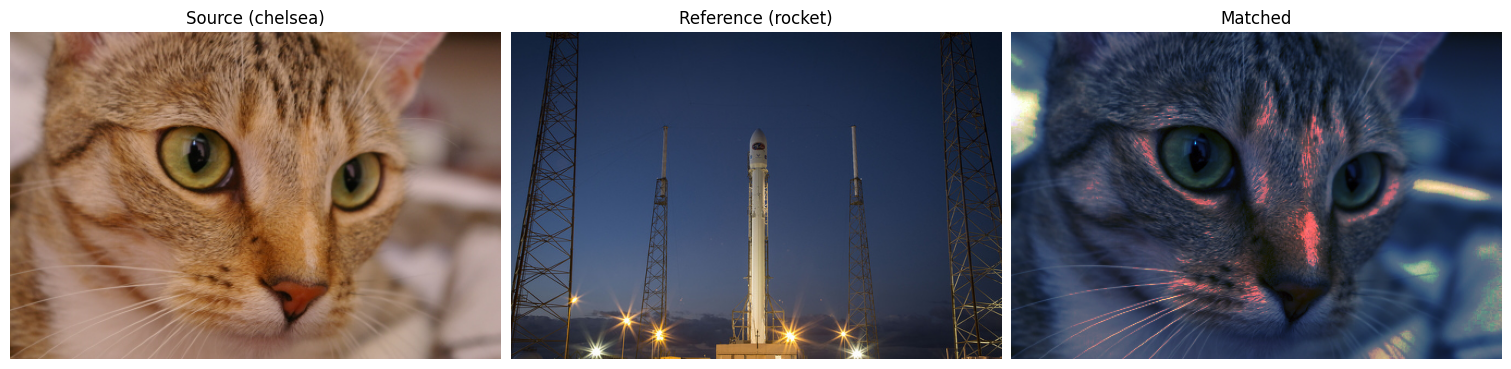

In [9]:
reference = data.rocket()
image = data.chelsea()

matched = exposure.match_histograms(image, reference, channel_axis=-1)
matched = np.clip(matched, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")
for ax, im, title in zip(axs, [image, reference, matched], ["Source (chelsea)", "Reference (rocket)", "Matched"]):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")
plt.show()

Per-channel cumulative histograms confirm the match: for each of R, G and B,
the matched image's CDF (third column) follows the reference's (second column)
rather than the source's (first column).

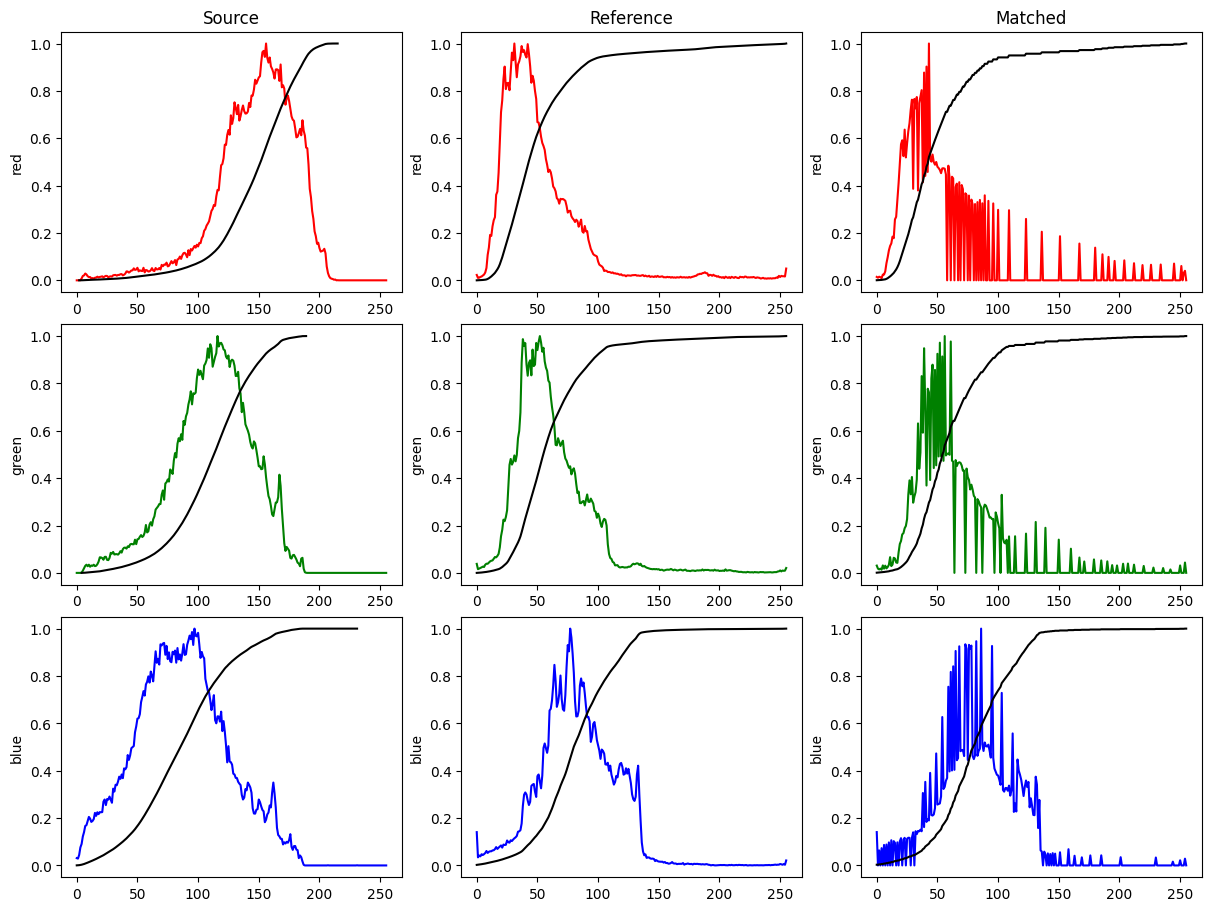

In [10]:
fig, axs = plt.subplots(3, 3, figsize=(12, 9), layout="constrained")
for col, im in enumerate([image, reference, matched]):
    for row, color in enumerate(["red", "green", "blue"]):
        hist, bins = exposure.histogram(im[..., row], source_range="dtype")
        axs[row, col].plot(bins, hist / hist.max(), color=color)
        cdf, bins = exposure.cumulative_distribution(im[..., row])
        axs[row, col].plot(bins, cdf, "k")
        axs[row, col].set_ylabel(color)
for ax, title in zip(axs[0], ["Source", "Reference", "Matched"]):
    ax.set_title(title)
plt.show()

## Resources

- Hands-On Image Processing with Python (book)
- <https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_equalize.html>
- <https://scikit-image.org/docs/0.24.x/auto_examples/color_exposure/plot_histogram_matching.html>